In [9]:
# Import the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.datasets import get_rdataset
import warnings
warnings.filterwarnings("ignore")

In [2]:
# --- Section 1: Data Preparation ---
# Load a real-world dataset that is already stationary.
# The 'lutenizing hormone' dataset is a classic example.
print("Loading the Luteinizing Hormone dataset...")

lh_data = get_rdataset("lh", "datasets").data
stationary_series = lh_data['value']

Loading the Luteinizing Hormone dataset...


In [3]:
date_index = pd.date_range(start='1970-01-01', periods=len(stationary_series), freq='MS')
stationary_series.index = date_index

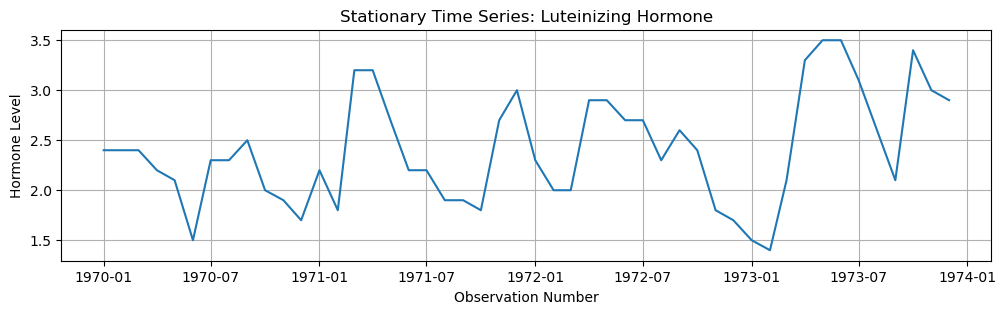

In [4]:
# Plot the series to visually confirm it is stationary.
# You will see no clear upward or downward trend.
plt.figure(figsize=(12, 3))
plt.plot(stationary_series)
plt.title('Stationary Time Series: Luteinizing Hormone')
plt.xlabel('Observation Number')
plt.ylabel('Hormone Level')
plt.grid(True)
plt.show()

In [7]:
def check_stationarity(series, test_name):
    """
    Performs and prints the results of the ADF and KPSS tests.
    
    Args:
        series (pd.Series): The time series to test.
        test_name (str): A descriptive name for the series being tested.
    """
    print(f"\n--- Results for the {test_name} series ---")
    
    # Augmented Dickey-Fuller (ADF) Test
    # H0: The series is non-stationary (has a unit root)
    adf_result = adfuller(series)
    print("ADF Test:")
    print(f"  Test Statistic: {adf_result[0]:.4f}")
    print(f"  P-value: {adf_result[1]:.4f}")
    print("  Interpretation:")
    if adf_result[1] > 0.05:
        print("  --> Fails to reject H0. The series is likely non-stationary.")
    else:
        print("  --> Rejects H0. The series is likely stationary.")
    
    # Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test
    # H0: The series is stationary
    try:
        kpss_result = kpss(series, regression='c')
        print("\nKPSS Test:")
        print(f"  Test Statistic: {kpss_result[0]:.4f}")
        print(f"  P-value: {kpss_result[1]:.4f}")
        print("  Interpretation:")
        if kpss_result[1] < 0.05:
            print("  --> Rejects H0. The series is likely non-stationary.")
        else:
            print("  --> Fails to reject H0. The series is likely stationary.")
    except Exception as e:
        print("\nKPSS Test could not be performed due to an error:")
        print(f"  Error: {e}")

In [10]:
check_stationarity(stationary_series,'stationary_series')


--- Results for the stationary_series series ---
ADF Test:
  Test Statistic: -3.6777
  P-value: 0.0044
  Interpretation:
  --> Rejects H0. The series is likely stationary.

KPSS Test:
  Test Statistic: 0.2938
  P-value: 0.1000
  Interpretation:
  --> Fails to reject H0. The series is likely stationary.


In [ ]:
ARIMA -> d -> 0 -> ARMA, p, q


Plotting ACF and PACF for the stationary series...


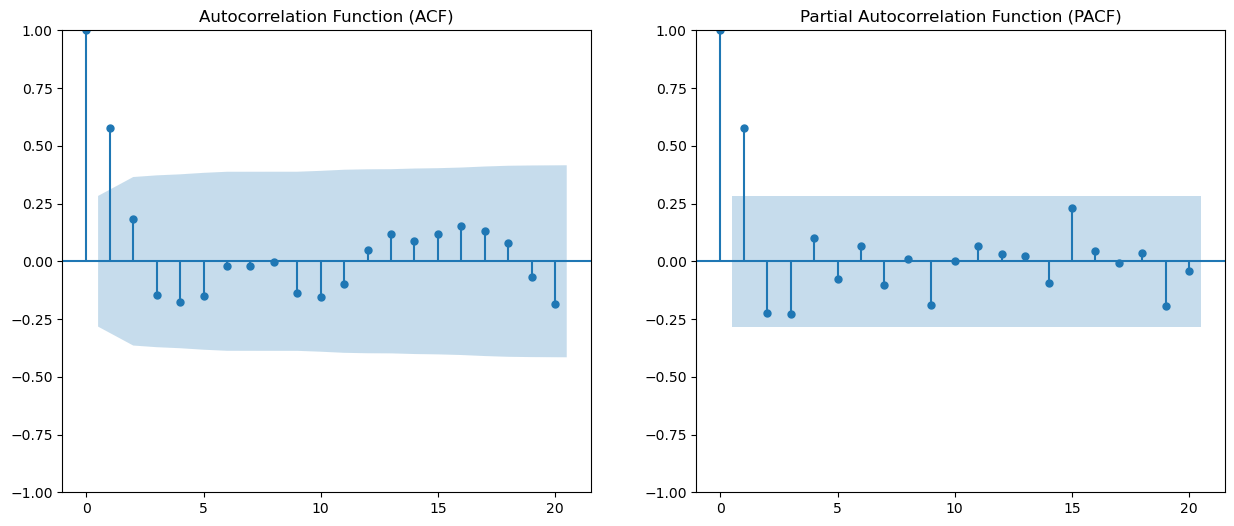

In [11]:
print("\nPlotting ACF and PACF for the stationary series...")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
plot_acf(stationary_series, ax=axes[0], lags=20, title='Autocorrelation Function (ACF)')
plot_pacf(stationary_series, ax=axes[1], lags=20, title='Partial Autocorrelation Function (PACF)')
plt.show()

In [ ]:
p = 1
q = 1

In [12]:
# We'll fit an ARMA(1, 1) model on the training data.
print("\nFitting a combined ARMA(1, 1) model on the training data...")
arma_model = ARIMA(stationary_series, order=(1, 0, 1))
arma_result = arma_model.fit()


Fitting a combined ARMA(1, 1) model on the training data...


In [14]:
# We'll fit an ARMA(1, 1) model on the training data.
print("\nFitting a combined ARMA(1, 1) model on the training data...")
arma_model = ARIMA(stationary_series, order=(2, 0, 2))
arma_result = arma_model.fit()


Fitting a combined ARMA(1, 1) model on the training data...


In [15]:
arma_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  value   No. Observations:                   48
Model:                 ARIMA(2, 0, 2)   Log Likelihood                 -27.213
Date:                Sun, 17 Aug 2025   AIC                             66.426
Time:                        12:23:45   BIC                             77.654
Sample:                    01-01-1970   HQIC                            70.669
                         - 12-01-1973                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.3954      0.140     17.103      0.000       2.121       2.670
ar.L1          0.8917      0.462      1.929      0.054      -0.014       1.798
ar.L2         -0.4863      0.275     -1.769      0.077      -1.025       0.052
ma.L1         -0.2299      0.492     -0.467      0.640      -1.195       0.735
ma.L2          0.2476      0.435      0.570      0.569      -0.604       1.100
sigma2         0.1796      0.040      4.479      0.000       0.101       0.258
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 8.04
Prob(Q):                              0.96   Prob(JB):                         0.02
Heteroskedasticity (H):               1.43   Skew:                             0.88
Prob(H) (two-sided):                  0.48   Kurtosis:                         3.97
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [16]:
# --- Section 3: Splitting the Data and Fitting the Model ---
# To evaluate our forecast, we'll split the data into a training set and a test set.
train_size = int(len(stationary_series) * 0.8)
train_data, test_data = stationary_series[:train_size], stationary_series[train_size:]

In [17]:
# We'll fit an ARMA(1, 1) model on the training data.
print("\nFitting a combined ARMA(1, 1) model on the training data...")
arma_model = ARIMA(train_data, order=(1, 0, 1))
arma_result = arma_model.fit()


Fitting a combined ARMA(1, 1) model on the training data...


In [18]:
# Print the ARMA model summary
print("\nARMA(1, 1) Model Summary:")
print(arma_result.summary())


ARMA(1, 1) Model Summary:
                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                   38
Model:                 ARIMA(1, 0, 1)   Log Likelihood                 -18.262
Date:                Sun, 17 Aug 2025   AIC                             44.524
Time:                        12:24:38   BIC                             51.074
Sample:                    01-01-1970   HQIC                            46.855
                         - 02-01-1973                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.2403      0.153     14.604      0.000       1.940       2.541
ar.L1          0.4021      0.432      0.931      0.352      -0.445       1.249
ma.L1          0.1724    

In [19]:
# --- Section 4: Forecasting and Evaluation ---
# We will now use the fitted model to forecast on the test data.
print("\nForecasting the next 10 periods...")
forecast_steps = len(test_data)
forecast_values = arma_result.forecast(steps=forecast_steps)


Forecasting the next 10 periods...


In [20]:
# Create a DataFrame to hold the actual and forecasted values for easy comparison
forecast_df = pd.DataFrame({
    'Actual': test_data.values,
    'Forecast': forecast_values.values
}, index=test_data.index)

print("\nActual vs. Forecasted Values:")
print(forecast_df)


Actual vs. Forecasted Values:
            Actual  Forecast
1973-03-01     2.1  1.823025
1973-04-01     3.3  2.072550
1973-05-01     3.5  2.172879
1973-06-01     3.5  2.213219
1973-07-01     3.1  2.229439
1973-08-01     2.6  2.235961
1973-09-01     2.1  2.238583
1973-10-01     3.4  2.239637
1973-11-01     3.0  2.240061
1973-12-01     2.9  2.240232


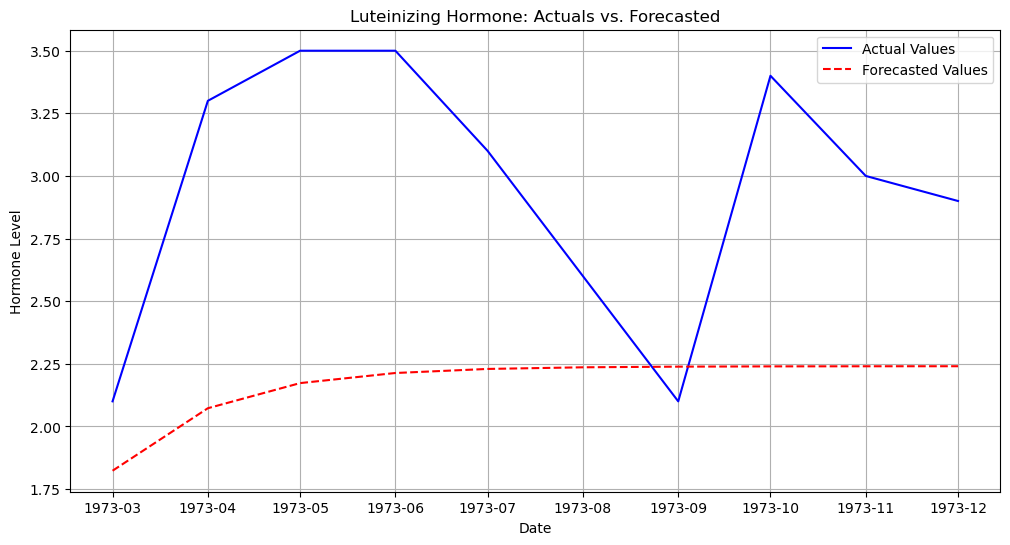

In [21]:
plt.figure(figsize=(12, 6))
plt.plot(test_data, label='Actual Values', color='blue')
plt.plot(forecast_values, label='Forecasted Values', color='red', linestyle='--')
plt.title('Luteinizing Hormone: Actuals vs. Forecasted')
plt.xlabel('Date')
plt.ylabel('Hormone Level')
plt.legend()
plt.grid(True)
plt.show()